We have completed the EDA and data cleaning part in the previous notebook.
Now we are in the second part of our project --- Model training.
Using the cleaned data set we will train our model and in the later part
we will use hyperparameter tuning to fine tune our model

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('cleaned_dataset.csv')

Now we will separate our dependent and independent features

In [3]:
x = df.drop('FWI', axis=1)
y = df['FWI']

In [4]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [5]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

Creating a train test split

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [7]:
x_train.shape, x_test.shape

((182, 11), (61, 11))

Feature selection based on correlation

In [8]:
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

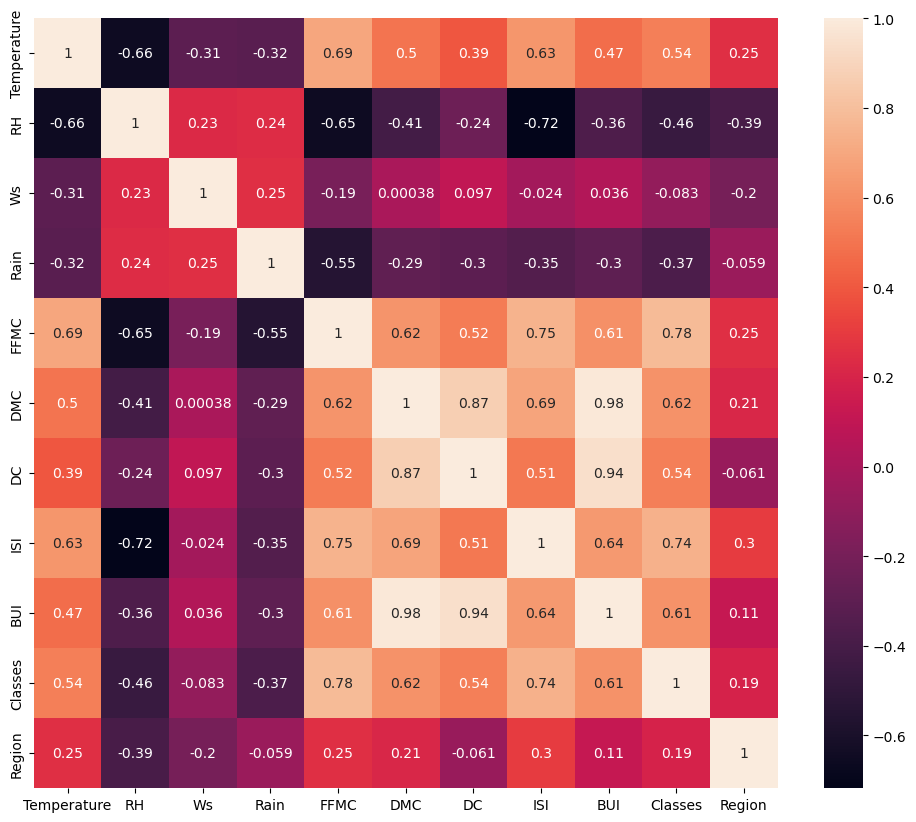

In [9]:
plt.figure(figsize=(12,10))
corr = x_train.corr()
sns.heatmap(corr, annot=True)

In [10]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [11]:
col_corr=correlation(x_train, 0.85)
print(col_corr)

{'BUI', 'DC'}


In [12]:
x_train.drop(col_corr, axis=1, inplace=True)
x_test.drop(col_corr, axis=1, inplace=True)

In [13]:
x_train.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
97,29,74,19,0.1,75.8,3.6,2.1,0,0
141,31,72,14,0.2,60.2,3.8,0.8,0,1
192,40,31,15,0.0,94.2,22.5,16.6,1,1
68,32,60,18,0.3,77.1,11.3,2.2,0,0
119,32,47,14,0.7,77.5,7.1,1.8,0,0


In [14]:
x_test.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
24,31,64,15,0.0,86.7,14.2,5.7,1,0
6,33,54,13,0.0,88.2,9.9,6.4,1,0
152,28,58,18,2.2,63.7,3.2,1.2,0,1
232,34,58,13,0.2,79.5,18.7,2.1,0,1
238,30,65,14,0.0,85.4,16.0,4.5,1,1


Highly correlated columns have been dropped now

##### Feature scaling or standardization

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [16]:
x_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]])

### Box plots to understand the positive reinforcement of standard scaler 

Text(0.5, 1.0, 'Training data after scaling')

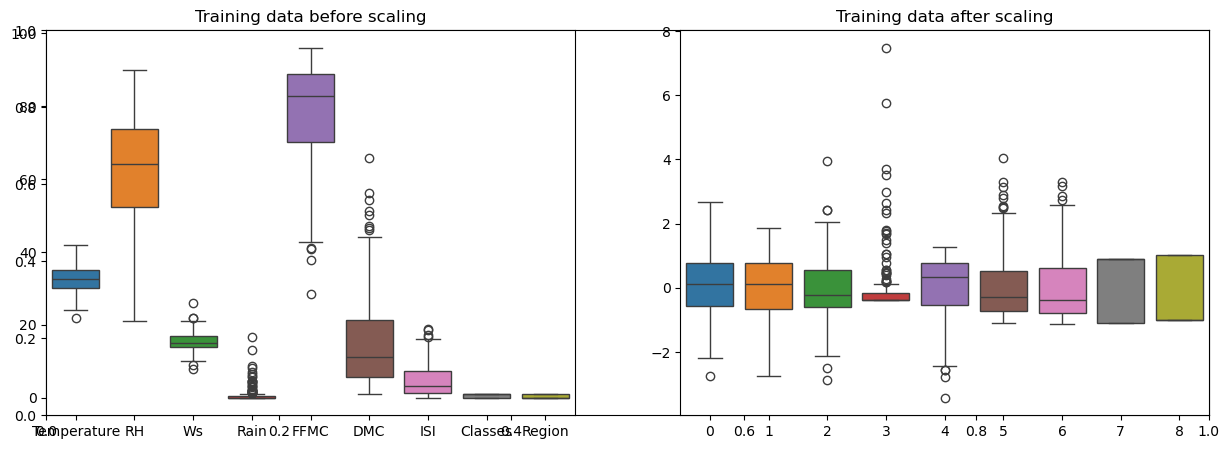

In [17]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title("Training data before scaling")
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title("Training data after scaling")

## Linear regression model 

In [18]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

Mean absolute error: 0.5468236465249995
R square value: 0.9847657384266951


Text(0, 0.5, 'Predicted values')

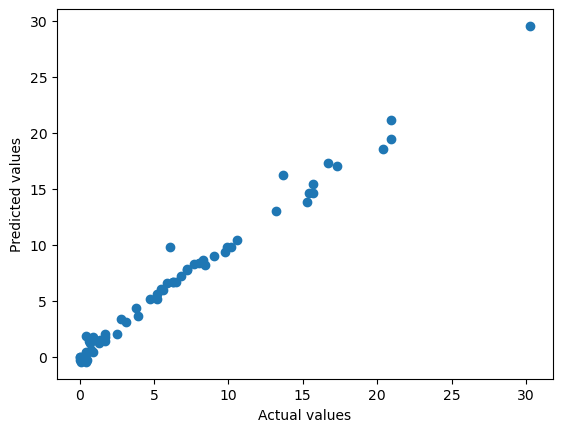

In [19]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(x_train_scaled, y_train)
y_pred = linreg.predict(x_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print(f'Mean absolute error: {mae}')
print(f'R square value: {score}')
plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")

## Lasso Regression model 

Mean absolute error: 1.1331759949144087
R square value: 0.9492020263112388


Text(0, 0.5, 'Predicted values')

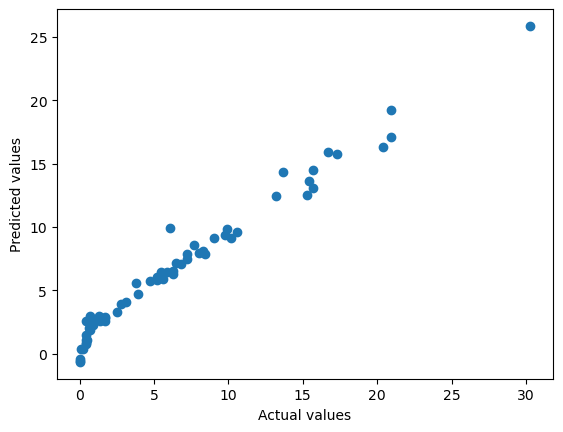

In [20]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(x_train_scaled, y_train)
y_pred = lasso.predict(x_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print(f'Mean absolute error: {mae}')
print(f'R square value: {score}')
plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")

## Ridge regression 

Mean absolute error: 0.5642305340105677
R square value: 0.9842993364555515


Text(0, 0.5, 'Predicted values')

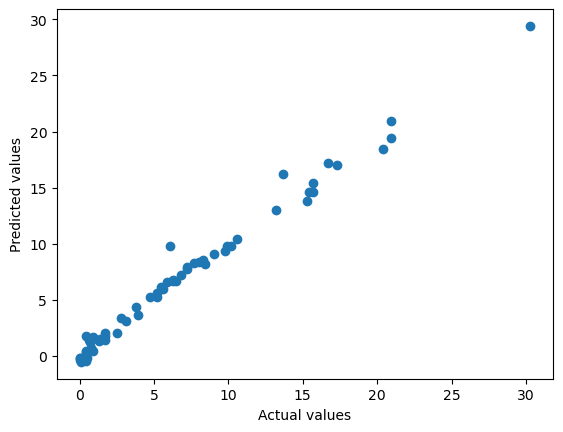

In [21]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(x_train_scaled, y_train)
y_pred = ridge.predict(x_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print(f'Mean absolute error: {mae}')
print(f'R square value: {score}')
plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")

## Elastic net regression

Mean absolute error: 1.8822353634896005
R square value: 0.8753460589519703


Text(0, 0.5, 'Predicted values')

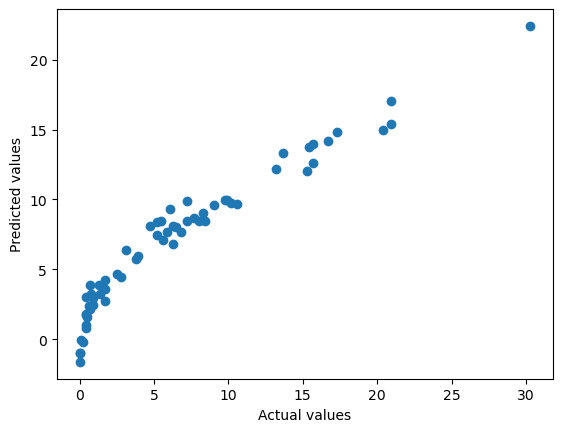

In [22]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet()
elastic.fit(x_train_scaled, y_train)
y_pred = elastic.predict(x_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print(f'Mean absolute error: {mae}')
print(f'R square value: {score}')
plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")

Now let's do one with cross validation method

Mean absolute error: 0.6575946731430896
R square value: 0.9814217587854942


Text(0, 0.5, 'Predicted values')

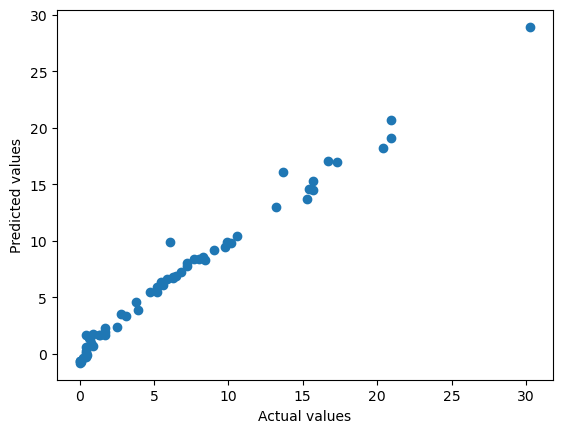

In [23]:
from sklearn.linear_model import ElasticNetCV

elasticCV = ElasticNetCV()
elasticCV.fit(x_train_scaled, y_train)
y_pred = elasticCV.predict(x_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print(f'Mean absolute error: {mae}')
print(f'R square value: {score}')
plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")

## Assumptions to see whether our model is really performing well 
### 1. y test vs. y predicted (The Accuracy Check)
This plot will show how close your predictions are to the actual truth.

The Goal: we want to see a tight, linear diagonal line (y=x). If every prediction is perfect, all points would sit exactly on a 45-degree line.

The Cases:

*1. Tight Diagonal*: Great! our model has captured the relationship well.

*2. Wide Cloud*: Our model is weak. It’s "guessing" in the right direction, but with high error (low R2).

*3. Curved Shape*: Our model is trying to fit a straight line to data that is actually curved. You might need a non-linear model.

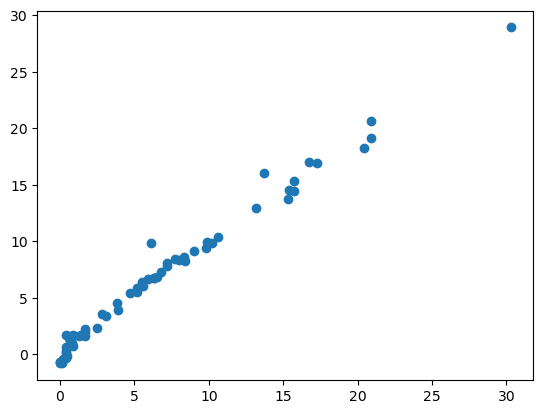

In [24]:
plt.scatter(y_test, y_pred)
plt.show()

In [25]:
residuals = y_test - y_pred
residuals

24     0.131037
6     -0.604990
152    0.603735
232   -0.791000
238   -0.387253
         ...   
162   -0.194937
178   -0.164863
224   -0.014480
230    0.822689
154   -0.300929
Name: FWI, Length: 61, dtype: float64

### 2. Distribution of Residuals (The Error Check)
A residual is simply the "leftover" error: Residual=y actual−y predicted

The Goal: A Normal Distribution (Bell Curve) centered at zero.

Why it matters: If the errors are normally distributed, it means your model is "wrong" only by random chance.

The Cases:

*1. Bell Curve at Zero*: Perfect. The errors are truly random.

*2. Skewed (Leaning Left/Right)*: Your model is systematically over-predicting or under-predicting certain ranges.

*3. Bimodal (Two bumps)*: You might be missing a major category or variable in your data that splits the results.

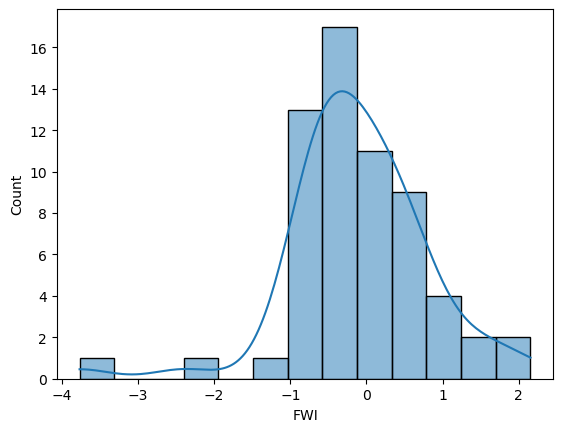

In [26]:
import seaborn as sns
sns.histplot(residuals, kde=True)
plt.show()

### y predicted vs. Residuals (The Homoscedasticity Check)
This is a fancy way of checking if your model’s "guessing ability" is consistent across all values.

The Goal: A "Uniform Cloud" or a random horizontal band. You shouldn't see any discernable shape.

The Cases:

*1. The "Funnel" Shape:* This is called Heteroscedasticity. It means your model is good at predicting small values but gets wildly inaccurate as the values get larger. (Common in income data—it's easier to predict the spending of someone making 30k than someone making 3M).

*2. The "U" or "S" Shape:* This means there is a pattern in the data that your linear model completely missed. You’ve left "information" in the errors.

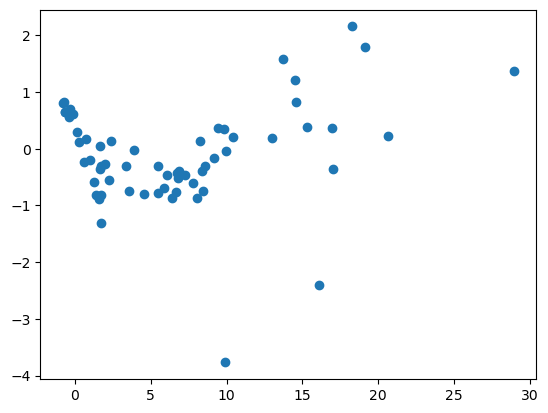

In [27]:
plt.scatter(y_pred, residuals)
plt.show()

In [28]:
import pickle 
pickle.dump(elasticCV, open('elasticCV.pkl', 'wb'))

In [29]:
model = pickle.load(open('elasticCV.pkl', 'rb'))

In [30]:
model.predict(x_test_scaled)

array([ 8.26896303,  7.80499035, -0.10373519,  4.5910001 ,  6.88725274,
        1.59410811,  2.35512483,  8.0623476 ,  1.72415002,  3.53713054,
        0.6324586 ,  9.86752845,  9.43037004, 16.93741658, 18.24537235,
        1.65750426,  1.70187606, -0.64660717,  7.25494999,  3.39769372,
        1.6585457 ,  0.11316128,  6.66222016,  0.2768868 , 20.66780763,
        5.47501303,  6.05587139,  9.84868106, -0.65326652,  9.93266416,
        6.72851251, -0.29425171, 10.39747097, 14.48835483,  1.70083377,
        0.73634118,  2.25453683,  6.37570352, -0.71507088, -0.36129277,
        6.8083341 ,  1.96274355,  8.60448104, -0.79781122, 15.32067065,
        8.39541208,  8.43742252,  1.41818555, 13.00237268,  1.28988758,
       28.93275959,  5.88819725, 17.04972357, 19.1125176 , 13.71477759,
       16.09820311,  0.99493652,  9.16486312,  3.91448039, 14.57731138,
        5.50092909])

#### Now we will generate pickle files for the Standard scaler object and Ridge regression
#### Ridge Regression's MAE is lesser and R square score is closer to one

In [32]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(ridge, open('ridge.pkl', 'wb'))